# Time Series with weather data

In [10]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [11]:
# Load weather data
df = pd.read_csv("/home/sylas/Desktop/DSR/Project/data_unused/Weather_AEG01_2008_2023/AEG01_2008-23.csv")
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   plotID                 192 non-null    str    
 1   datetime               192 non-null    str    
 2   year                   192 non-null    int64  
 3   month                  192 non-null    int64  
 4   rH_200                 136 non-null    float64
 5   Ta_10                  141 non-null    float64
 6   SM_10                  127 non-null    float64
 7   SM_20                  123 non-null    float64
 8   Ts_10                  141 non-null    float64
 9   Ts_20                  141 non-null    float64
 10  Ta_200                 141 non-null    float64
 11  precipitation_radolan  192 non-null    float64
dtypes: float64(8), int64(2), str(2)
memory usage: 18.1 KB
None


,plotID,datetime,year,month,rH_200,Ta_10,SM_10,SM_20,Ts_10,Ts_20,Ta_200,precipitation_radolan
0,AEG01,2008-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.98
1,AEG01,2008-02,2008,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.80
2,AEG01,2008-03,2008,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.80
3,AEG01,2008-04,2008,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.48
4,AEG01,2008-05,2008,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79.20


In [12]:
#  Format datetime and set as index
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()

# Find the first date where each column starts having data
for col in df.columns:
    first_valid = df[col].first_valid_index()
    missing_count = df[col].isna().sum()
    print(f"{col:22s} | First valid date: {str(first_valid)[:10]} | Missing rows: {missing_count}")

plotID                 | First valid date: 2008-01-01 | Missing rows: 0
year                   | First valid date: 2008-01-01 | Missing rows: 0
month                  | First valid date: 2008-01-01 | Missing rows: 0
rH_200                 | First valid date: 2009-05-01 | Missing rows: 56
Ta_10                  | First valid date: 2009-05-01 | Missing rows: 51
SM_10                  | First valid date: 2009-05-01 | Missing rows: 65
SM_20                  | First valid date: 2009-05-01 | Missing rows: 69
Ts_10                  | First valid date: 2009-05-01 | Missing rows: 51
Ts_20                  | First valid date: 2009-05-01 | Missing rows: 51
Ta_200                 | First valid date: 2009-05-01 | Missing rows: 51
precipitation_radolan  | First valid date: 2008-01-01 | Missing rows: 0


In [41]:
# slice 'time' method takes exact date differences into account:
df_trimmed = df.loc['2009-05-01':].asfreq('MS')

# Find the first date where each column starts having data
for col in df_trimmed.columns:
    first_valid = df_trimmed[col].first_valid_index()
    missing_count = df_trimmed[col].isna().sum()
    print(f"{col:22s} | First valid date: {str(first_valid)[:10]} | Missing rows: {missing_count}")

# Check the longest streak of missing values in a column
missing_mask = df_trimmed['Ta_10'].isna()
max_gap = missing_mask.groupby((~missing_mask).cumsum()).sum().max()
print(f"Longest consecutive gap: {max_gap} months")

plotID                 | First valid date: 2009-05-01 | Missing rows: 0
year                   | First valid date: 2009-05-01 | Missing rows: 0
month                  | First valid date: 2009-05-01 | Missing rows: 0
rH_200                 | First valid date: 2009-05-01 | Missing rows: 40
Ta_10                  | First valid date: 2009-05-01 | Missing rows: 35
SM_10                  | First valid date: 2009-05-01 | Missing rows: 49
SM_20                  | First valid date: 2009-05-01 | Missing rows: 53
Ts_10                  | First valid date: 2009-05-01 | Missing rows: 35
Ts_20                  | First valid date: 2009-05-01 | Missing rows: 35
Ta_200                 | First valid date: 2009-05-01 | Missing rows: 35
precipitation_radolan  | First valid date: 2009-05-01 | Missing rows: 0
Longest consecutive gap: 25 months


In [49]:
# Show the dates where a column has the missing gap (NaN)
missing_rows = df_trimmed[df_trimmed['Ta_200'].isna()]

gap_start = missing_rows.index[0]
gap_end = missing_rows.index[-1]
print(f"Missing gap starts on: {gap_start.strftime('%Y-%m-%d')}")
print(f"Missing gap ends on:   {gap_end.strftime('%Y-%m-%d')}")
print(f"Total missing months:  {len(missing_rows)}")


Missing gap starts on: 2011-07-01
Missing gap ends on:   2017-11-01
Total missing months:  35


In [51]:

# Slice from the clean resumption period after the gap
df_trimmed2 = df.loc['2018-01-01':].copy()
df_trimmed2  = df_trimmed2 .asfreq('MS')

# Check how many months you have and if any missing values remain
print(f"Number of months available: {len(df_trimmed2)}")
print("Missing values per column:\n", df_trimmed2.isna().sum())

Number of months available: 72
Missing values per column:
 plotID                    0
year                      0
month                     0
rH_200                    1
Ta_10                     0
SM_10                    14
SM_20                     0
Ts_10                     0
Ts_20                     0
Ta_200                    0
precipitation_radolan     0
dtype: int64


In [54]:
# Show the dates where a column has the missing gap (NaN)
missing_rows = df_trimmed2[df_trimmed2['SM_10'].isna()]

gap_start = missing_rows.index[0]
gap_end = missing_rows.index[-1]
print(f"Missing gap on SM_10 starts on: {gap_start.strftime('%Y-%m-%d')}")
print(f"Missing gap on SM_10 ends on:   {gap_end.strftime('%Y-%m-%d')}")
print(f"Total missing months on SM_10:  {len(missing_rows)}")


Missing gap on SM_10 starts on: 2020-08-01
Missing gap on SM_10 ends on:   2021-09-01
Total missing months on SM_10:  14


## Seasonal Trend Loess (STL) Decomposition
>
> STL is a versatile and robust method for decomposing time series and estimating nonlinear relationships
>
> Advantages over the classical, SEATS and X11 decomposition methods:
>
> - Handle any type of seasonality, not only monthly and quarterly data.
> - The seasonal component is allowed to change over time, and the rate of change can be controlled by the user.
> - The smoothness of the trend-cycle can also be controlled by the user.
> - Can be robust to outliers (i.e., the user can specify a robust decomposition), so that occasional unusual observations will not affect the estimates of the trend-cycle and seasonal components. They will, however, affect the remainder component.
>
> Disadvantages
> 
> Does not handle trading day or calendar variation automatically, and it only provides facilities for additive decompositions._

In [55]:
y_Ta_10 = df_trimmed2['Ta_10'].asfreq('MS')
y_Ta_200 = df_trimmed2['Ta_200'].asfreq('MS')
y_ST_10 = df_trimmed2['Ts_10'].asfreq('MS')
y_ST_200 = df_trimmed2['Ts_20'].asfreq('MS')
y_SM_10 = df_trimmed2['SM_10'].asfreq('MS')
y_SM_20 = df_trimmed2['SM_20'].asfreq('MS')

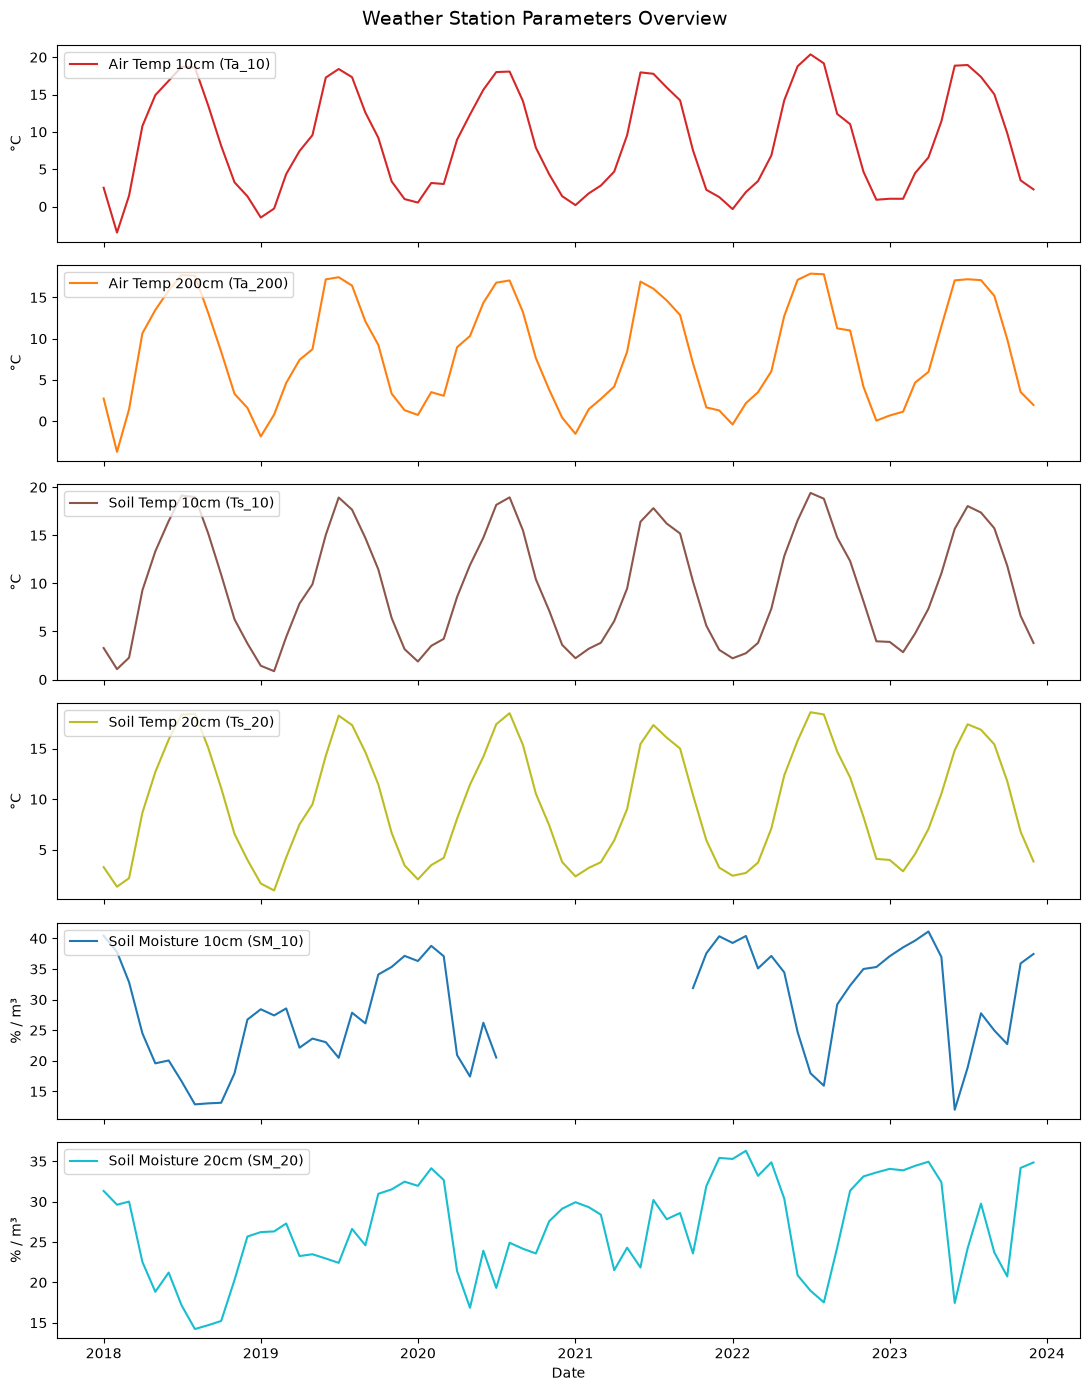

In [ ]:
# Create a figure with 6 stacked subplots
fig, axes = plt.subplots(6, 1, figsize=(11, 14), sharex=True)

# 1. Air Temperatures
axes[0].plot(y_Ta_10, color='tab:cyan', label='Air Temp 10cm (Ta_10)')
axes[0].set_ylabel('°C')
axes[0].legend(loc='upper left')

axes[1].plot(y_Ta_200, color='tab:blue', label='Air Temp 200cm (Ta_200)')
axes[1].set_ylabel('°C')
axes[1].legend(loc='upper left')

# 2. Soil Temperatures
axes[2].plot(y_ST_10, color='tab:orange', label='Soil Temp 10cm (Ts_10)')
axes[2].set_ylabel('°C')
axes[2].legend(loc='upper left')

axes[3].plot(y_ST_200, color='tab:brown', label='Soil Temp 20cm (Ts_20)')
axes[3].set_ylabel('°C')
axes[3].legend(loc='upper left')

# 3. Soil Moistures
axes[4].plot(y_SM_10, color='tab:green', label='Soil Moisture 10cm (SM_10)')
axes[4].set_ylabel('% / m³')
axes[4].legend(loc='upper left')

axes[5].plot(y_SM_20, color='tab:olive', label='Soil Moisture 20cm (SM_20)')
axes[5].set_ylabel('% / m³')
axes[5].legend(loc='upper left')

plt.xlabel('Date')
plt.suptitle('Weather Station Parameters Overview', fontsize=14, y=0.99)
plt.tight_layout()
plt.show()

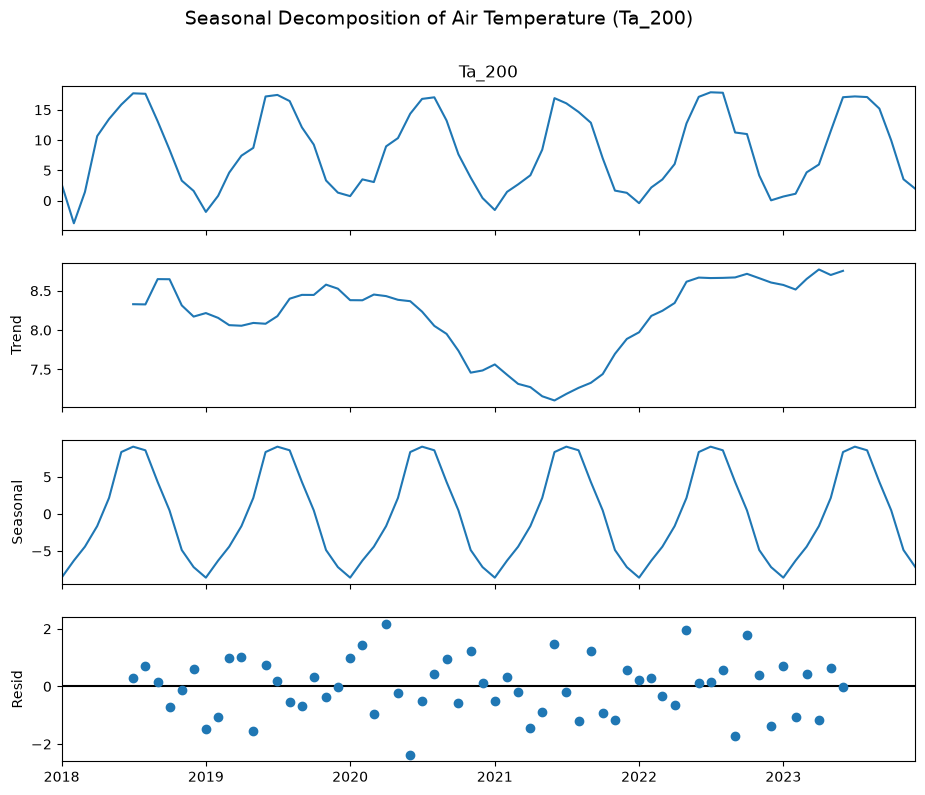

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp_Ta_200 = seasonal_decompose(y_Ta_200, model='additive', period=12)

# Plot the 4 components: Observed, Trend, Seasonal, Residuals
fig = decomp_Ta_200.plot()
fig.set_size_inches(10, 8)
fig.suptitle('Seasonal Decomposition of Air Temperature at 2 meters', fontsize=14, y=1.02)

# Label y-axis 
axes = fig.get_axes()
axes[0].set_ylabel("Observed (°C)")
axes[1].set_ylabel("Trend (°C)")
axes[2].set_ylabel("Seasonal (°C offset)")
axes[3].set_ylabel("Residual (°C error)")
plt.show()

In [ ]:
decomp_ST_20 = seasonal_decompose(y_ST_20, model='additive', period=12)

# Plot the 4 components: Observed, Trend, Seasonal, Residuals
fig = decomp_ST_20.plot()
fig.set_size_inches(10, 8)
fig.suptitle('Seasonal Decomposition of Air Temperature (ST_20)', fontsize=14, y=1.02)

# Label y-axis 
axes = fig.get_axes()
axes[0].set_ylabel("Observed (°C)")
axes[1].set_ylabel("Trend (°C)")
axes[2].set_ylabel("Seasonal (°C offset)")
axes[3].set_ylabel("Residual (°C error)")
plt.show()